In [1]:
from pathlib import Path
import sys

sys.path.append('..')
from utils import draw_pr_curve_from_cv_results

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from aeon.classification.interval_based import (
    TimeSeriesForestClassifier,
    DrCIFClassifier
)
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from aeon.transformations.collection import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = (train[[str(i) for i in range(100)]]
           .reset_index()
           .melt(id_vars='id', var_name='time'))
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])
train_X = train_X.sort_index().values.reshape((850, 1, 100))

In [6]:
type(train_X), train_X.shape

(numpy.ndarray, (850, 1, 100))

## Rating Category

In [7]:
train_y = train['rating_category']
train_y.shape

(850,)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
rating_scores = ('f1_macro', 'accuracy', 'precision_macro', 'recall_macro')

As a baseline we use the performance of a dummy classifier with strategy=stratified on the same folds we use for model selection.

In [10]:
%%capture --no-stdout
# Using cell magic to capture warning on zero division error because I couldn't see the results

dummy = DummyClassifier(strategy='stratified')
baseline = cross_validate(dummy, train_X, train_y, cv=cv, scoring=rating_scores)
for key, value in baseline.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1_macro: 0.20 (0.03)
accuracy: 0.29 (0.03)
precision_macro: 0.21 (0.03)
recall_macro: 0.20 (0.03)


### Time Series Forest

In [11]:
tsf = TimeSeriesForestClassifier(random_state=42)

pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('clf', tsf)
])

In [12]:

param_grid = {
    'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
    'clf__n_estimators': (5, 10, 50, 100, 200),
    'clf__max_interval_length': (.5, 1),
    'scaler': ('passthrough', Normalizer()),
}


grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring=('f1_macro'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True,
                    cv=cv)

In [13]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   1.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   1.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   1.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   1.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   1.2s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__m

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        TimeSeriesForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10, 50, 100, 200),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1_macro', verbose=2)

In [14]:
results = pd.DataFrame(grid.cv_results_)

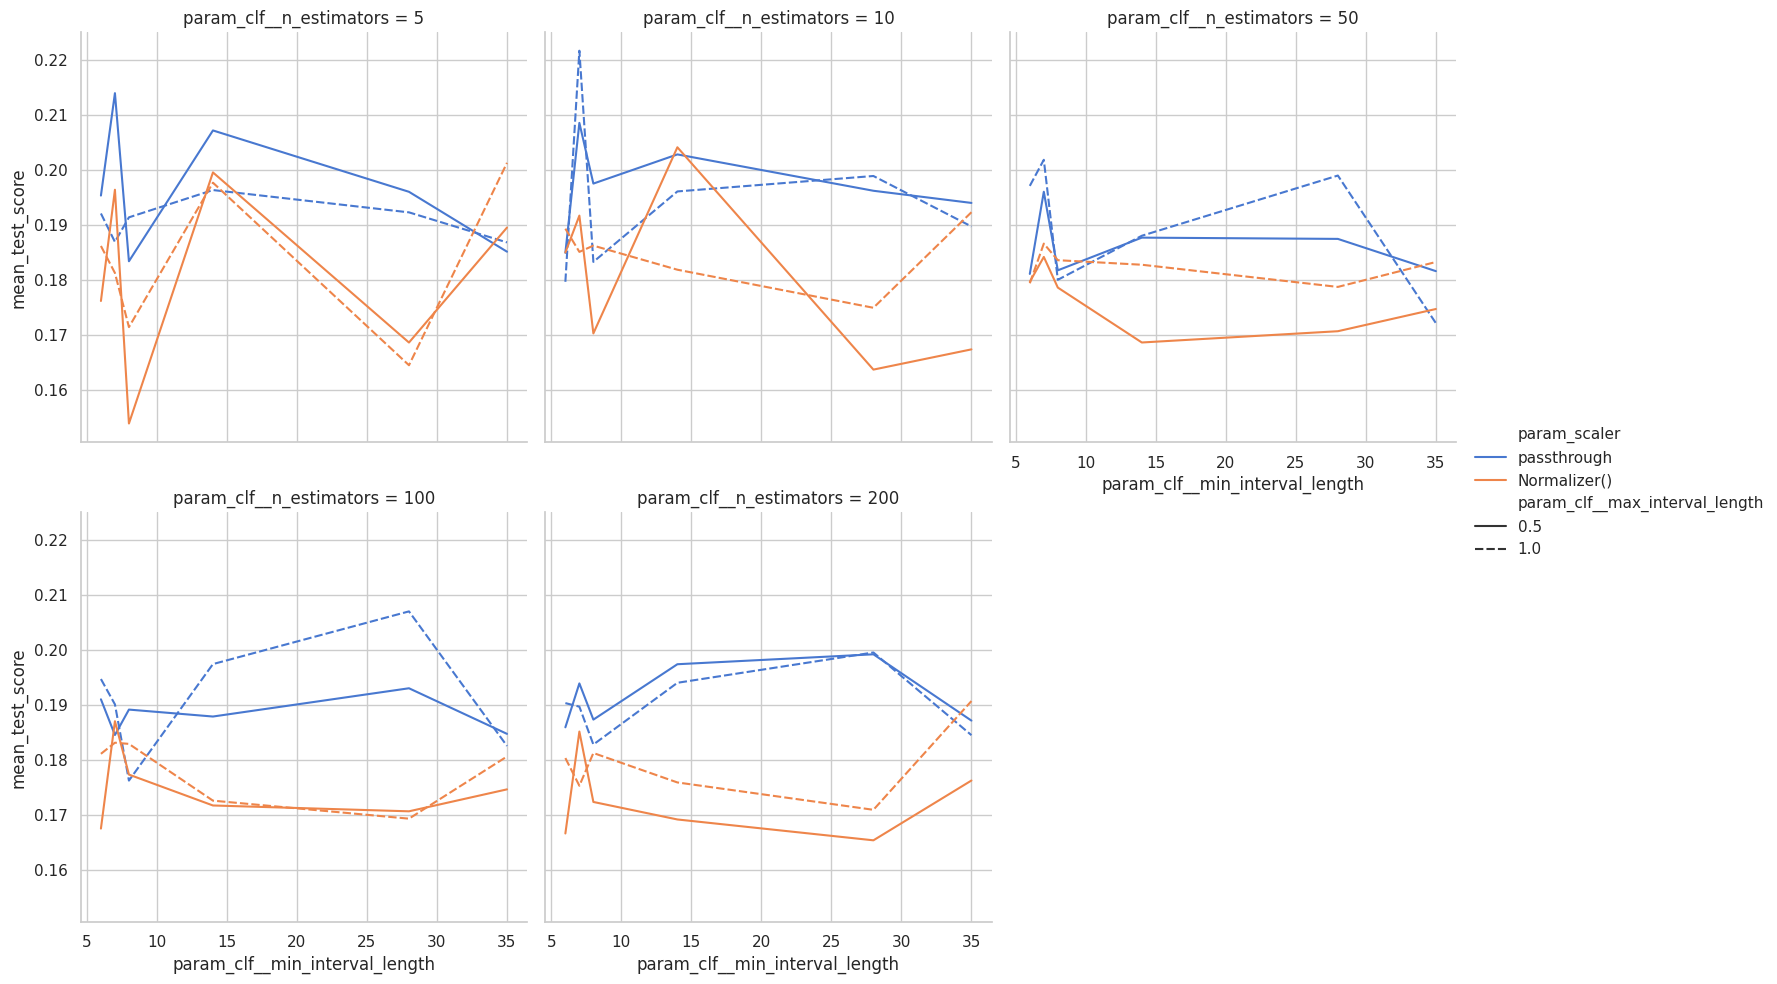

In [15]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length',
            col_wrap=3)

Even the best configuration of parameters gives results that don't that exceed the baseline's macro f1 only by .03.

In [16]:
grid.best_params_

{'clf__max_interval_length': 1,
 'clf__min_interval_length': 7,
 'clf__n_estimators': 10,
 'scaler': 'passthrough'}

In [17]:
%%capture --no-stdout

tsf_results = cross_validate(grid.best_estimator_, train_X, train_y, cv=cv, scoring=rating_scores, return_train_score=True)
for key, value in tsf_results.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1_macro: 0.22 (0.06)
accuracy: 0.32 (0.02)
precision_macro: 0.26 (0.10)
recall_macro: 0.23 (0.04)


In [18]:
print("Results on the training set:")
for key, value in tsf_results.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1_macro: 1.00 (0.00)
accuracy: 1.00 (0.00)
precision_macro: 1.00 (0.00)
recall_macro: 1.00 (0.00)


Performing cross validation we find out that the model is overfitting and performance on the test set is completely random.

### DrCif

In [19]:
drcif = DrCIFClassifier(random_state=42)

drcif_pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('clf', drcif)
])


dr_cif_param_grid = {
    'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
    'clf__n_estimators': (5, 10),
    'clf__max_interval_length': (.5, 1),
    'scaler': ('passthrough', Normalizer()),
}

grid = GridSearchCV(drcif_pipeline,
                    param_grid=dr_cif_param_grid,
                    scoring=('f1_macro'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True,
                    cv=cv)

In [20]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   7.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   7.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   7.4s
[CV] END clf__max_interval_length=0.5, clf__mi

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        DrCIFClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1_macro', verbose=2)

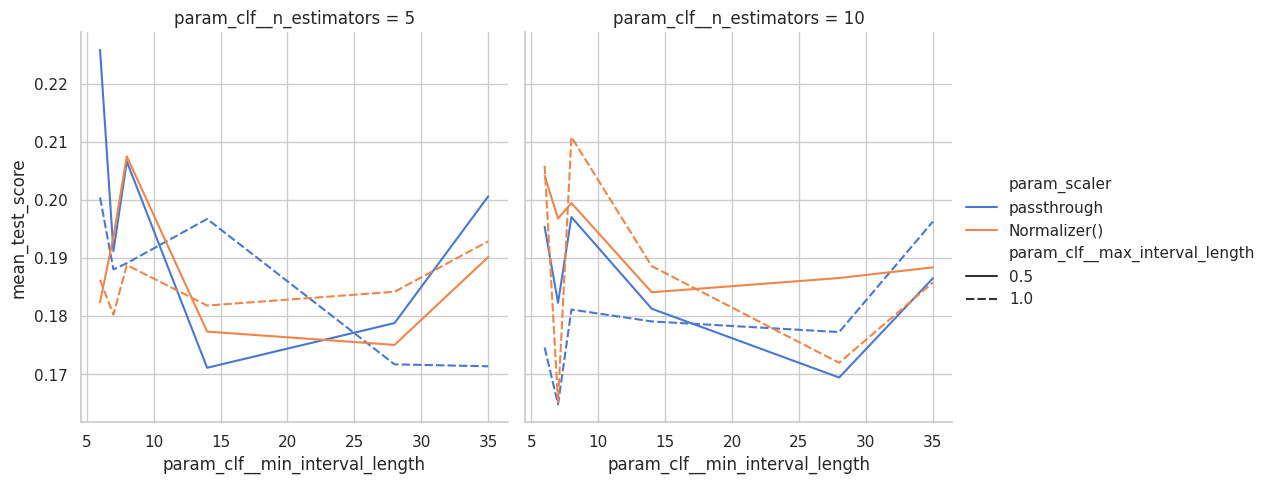

In [21]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length',
            col_wrap=2)

In [22]:
grid.best_params_

{'clf__max_interval_length': 0.5,
 'clf__min_interval_length': 6,
 'clf__n_estimators': 5,
 'scaler': 'passthrough'}

In [23]:
%%capture --no-stdout

drcif_results = cross_validate(grid.best_estimator_, train_X, train_y, cv=cv, scoring=rating_scores, return_train_score=True)
for key, value in drcif_results.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1_macro: 0.23 (0.05)
accuracy: 0.34 (0.02)
precision_macro: 0.25 (0.07)
recall_macro: 0.23 (0.04)


In [24]:
print("Results on the training set:")
for key, value in drcif_results.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1_macro: 1.00 (0.00)
accuracy: 1.00 (0.00)
precision_macro: 1.00 (0.00)
recall_macro: 1.00 (0.00)


same as time tsf.

## Action

In [25]:
train_y = train['action']

In [26]:
action_scores = ('f1', 'precision', 'recall', 'accuracy', 'average_precision')

In [27]:
%%capture --no-stdout
# Using cell magic to capture warning on zero division error because I couldn't see the results

dummy = DummyClassifier(strategy='stratified')
baseline = cross_validate(dummy, train_X, train_y, cv=cv, scoring=action_scores)
for key, value in baseline.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1: 0.28 (0.02)
precision: 0.29 (0.01)
recall: 0.27 (0.03)
accuracy: 0.56 (0.01)
average_precision: 0.31 (0.01)


### TSF

In [28]:
grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring=('f1'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True,
                    cv=cv)

In [29]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.5s
[CV] END clf__max_interval_length=0.5, clf__mi

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        TimeSeriesForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10, 50, 100, 200),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1', verbose=2)

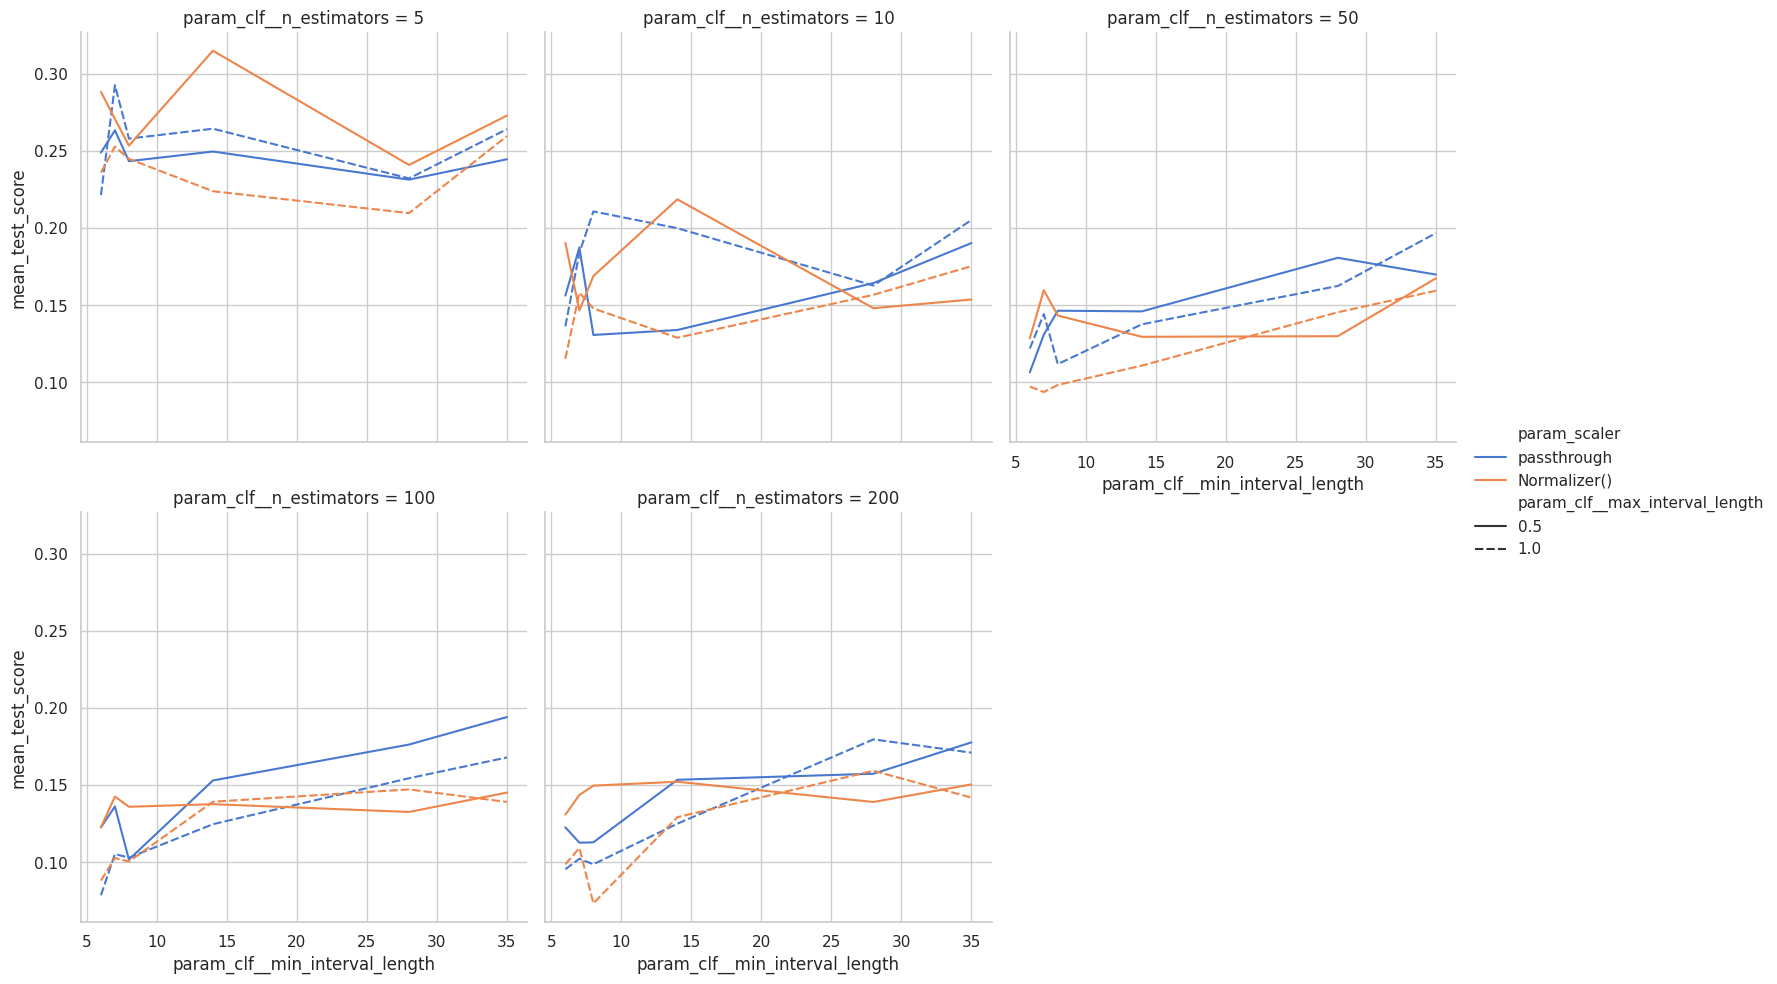

In [30]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length',
            col_wrap=3)

In [31]:
grid.best_params_

{'clf__max_interval_length': 0.5,
 'clf__min_interval_length': 14,
 'clf__n_estimators': 5,
 'scaler': Normalizer()}

In [32]:
%%capture --no-stdout

tsf_results_action = cross_validate(grid.best_estimator_, train_X, train_y, cv=cv, scoring=action_scores,
return_train_score=True, return_estimator=True, return_indices=True)
for key, value in tsf_results_action.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1: 0.32 (0.05)
precision: 0.37 (0.06)
recall: 0.27 (0.05)
accuracy: 0.62 (0.03)
average_precision: 0.35 (0.03)


In [33]:
print("Results on the training set:")
for key, value in tsf_results_action.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1: 1.00 (0.00)
precision: 1.00 (0.00)
recall: 1.00 (0.00)
accuracy: 1.00 (0.00)
average_precision: 1.00 (0.00)


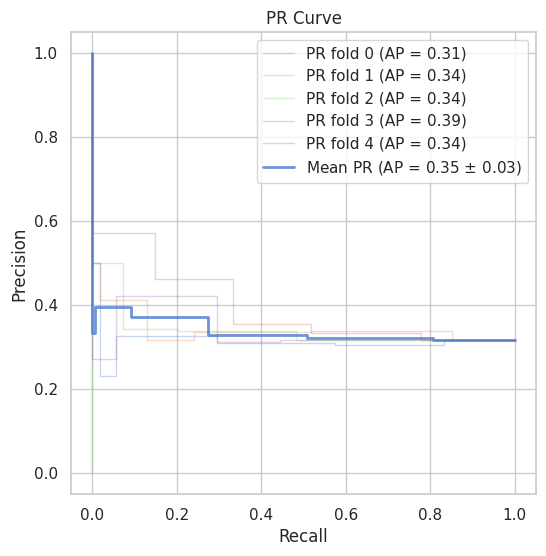

In [34]:
draw_pr_curve_from_cv_results(tsf_results_action, train_X, train_y)

### DrCif

In [35]:
grid = GridSearchCV(drcif_pipeline,
                    param_grid=dr_cif_param_grid,
                    scoring=('f1'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True,
                    cv=cv)

In [36]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=  18.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=  17.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=  18.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=  17.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=  18.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=  18.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=  18.5s
[CV] END clf__max_interval_length=0.5, clf__mi

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        DrCIFClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1', verbose=2)

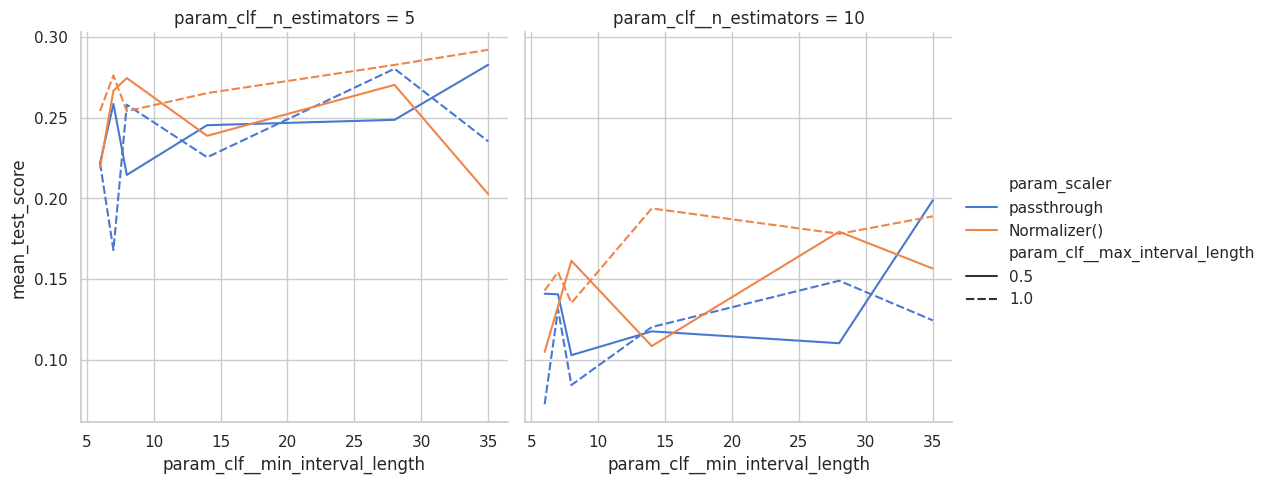

In [37]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length',
            col_wrap=2)

In [38]:
grid.best_params_

{'clf__max_interval_length': 1,
 'clf__min_interval_length': 35,
 'clf__n_estimators': 5,
 'scaler': Normalizer()}

In [39]:
%%capture --no-stdout

drcif_results_action = cross_validate(grid.best_estimator_, train_X, train_y, cv=cv, scoring=action_scores,
return_train_score=True, return_estimator=True, return_indices=True)
for key, value in drcif_results_action.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1: 0.29 (0.04)
precision: 0.35 (0.05)
recall: 0.25 (0.04)
accuracy: 0.61 (0.02)
average_precision: 0.34 (0.02)


In [40]:
print("Results on the training set:")
for key, value in drcif_results_action.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1: 1.00 (0.00)
precision: 1.00 (0.00)
recall: 1.00 (0.00)
accuracy: 1.00 (0.00)
average_precision: 1.00 (0.00)


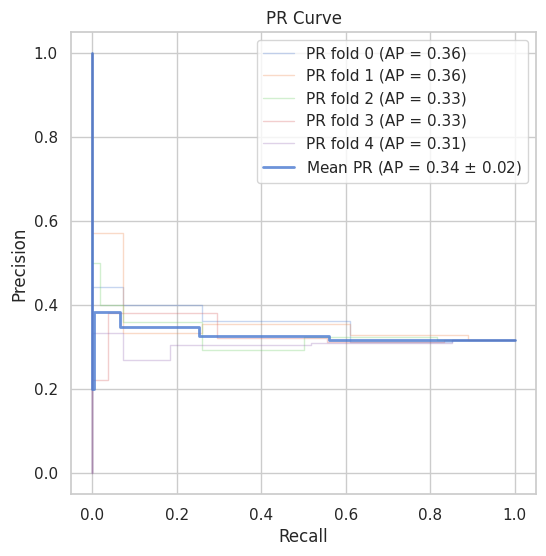

In [41]:
draw_pr_curve_from_cv_results(drcif_results_action, train_X, train_y)